In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
import numpy as np 
import networkx as nx
import tqdm
import igraph as ig
import random
from yaml import load, Loader
conf = load(open("conf.yaml"), Loader)
db.toc()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

virus_hits_pvt = virus_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')
bacteria_hits_pvt = bacteria_hits.drop_duplicates(subset=['scientific_name', 'library'], keep='first')

In [3]:
bacteria_hits_pvt['foo'] = 1
bacteria_hits_pvt = bacteria_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)
virus_hits_pvt['foo'] = 1
virus_hits_pvt = virus_hits_pvt.pivot(index='scientific_name', columns='library', values='foo').fillna(0)


In [4]:
M = pd.concat([virus_hits_pvt, bacteria_hits_pvt]).fillna(0)
assert(len(M) == 158 + 127) # To check that we have the same number of bacteria  virus

In [5]:
M

library,PV001,PV002,PV003,PV003bgi,PV004bgi,PV005bgi,PV006bgi,PV007bgi,PV008bgi,PV009,...,PV068,PV298,PV350,PV546,PV557,PV565,PV572,PV576,PV577,PV583
scientific_name,,,,,,,,,,,,,,,,,,,,,
African eggplant yellowing virus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ageratum latent virus RNA 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alfalfa enamovirus 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alfalfa mosaic virus RNA 2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Arabidopsis halleri partitivirus 1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Stutzerimonas stutzeri,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Variovorax paradoxus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Xanthomonas campestris,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Mixing

In [6]:
rows = M.index.to_list()
columns = M.index.to_list()
values = M.values.copy()

## Randomization

In [7]:
def randomize_matrix(values):
    Z = np.zeros_like(values)
    for i in range(len(values[:, 0])):

        Z[i, :] = np.random.permutation(values[i, :])
    
    assert(Z.sum() == values.sum())
    return Z


In [8]:
Z1 = randomize_matrix(values)
Z2 = randomize_matrix(values)
assert(not np.all(Z1 == Z2))

In [9]:
def compute_codetection(values):
    C = np.zeros((len(values[:, 0]), len(values[:, 0])))
    for i in range(len(values[:, 0])):
        for j in range(len(values[:, 0])):
            C[i, j] = values[i, :] @ values[j, :]

    return C

In [10]:
compute_codetection(
    np.array(
        [
            [1, 0, 1, 0, 1],
            [0, 1, 0, 0, 1],
            [1, 0, 1, 0, 1],
        ]
    )
)

array([[3., 1., 3.],
       [1., 2., 1.],
       [3., 1., 3.]])

In [11]:
CC = []
for i in tqdm.tqdm(range(1000)):

    Z = randomize_matrix(values)
    C = compute_codetection(Z)
    CC.append(C)

100%|██████████| 1000/1000 [01:09<00:00, 14.45it/s]


In [12]:
CC = np.stack(CC, axis=2)

In [13]:
true_C = compute_codetection(values)

In [14]:
P = np.zeros_like(true_C) # Positive
Q = np.zeros_like(true_C) # Negative

for i in range(len(C[0, :])):
    for j in range(len(C[:, 0])):
        P[i, j] = np.sum(true_C[i, j] < CC[i, j, :]) / len(CC[i, j, :])

In [15]:
columns.index("Rubus chlorotic mottle virus")

109

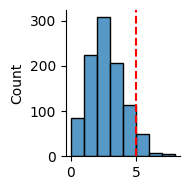

In [16]:
g = sns.displot(CC[rows.index("Duffyella gerundensis"), columns.index("Beet western yellows virus"), :], bins=8, height=2.0)
g.ax.axvline(true_C[rows.index("Duffyella gerundensis"), columns.index("Beet western yellows virus")], color='red', linestyle='--')

In [17]:
P_df = pd.DataFrame(P, columns=columns, index=rows).reset_index().melt(id_vars='index', value_vars=columns).rename(columns={'index': 'sp1', 'variable':'sp2', 'value': 'p'})
C_df = pd.DataFrame(true_C, columns=columns, index=rows).reset_index().melt(id_vars='index', value_vars=columns).rename(columns={'index': 'sp1', 'variable':'sp2', 'value': 'observed'})
CC_df = pd.DataFrame(CC.mean(2), columns=columns, index=rows).reset_index().melt(id_vars='index', value_vars=columns).rename(columns={'index': 'sp1', 'variable':'sp2', 'value': 'expected'})

A = pd.merge(pd.merge(P_df, C_df), CC_df).query('expected > 1.0').query('p > 0.975 or p < 0.025').query('sp1 != sp2')
A

,sp1,sp2,p,observed,expected
1564,Turnip crinkle virus,Arabidopsis latent virus-1 RNA1,0.003,4.0,1.193
1581,Youcai mosaic virus,Arabidopsis latent virus-1 RNA1,0.001,4.0,1.190
1628,Frigoribacterium sp. Leaf164,Arabidopsis latent virus-1 RNA1,0.016,3.0,1.141
2959,Rubus chlorotic mottle virus,Barley virus G,0.018,3.0,1.448
3166,Brassica yellows virus isolate,Barley yellow dwarf virus - GAV,0.005,4.0,1.334
...,...,...,...,...,...
78136,Cucumber mosaic virus RNA 3,Sphingomonas sp. Leaf231,0.000,2.0,1.227
79276,Cucumber mosaic virus RNA 3,Stenotrophomonas maltophilia,0.000,5.0,3.141
79339,Rubus chlorotic mottle virus,Stenotrophomonas maltophilia,0.009,4.0,1.861
80451,Parietaria mottle virus RNA 3,Xanthomonas campestris,0.006,4.0,1.353


In [18]:
virus_index = virus_hits_pvt.reset_index()[['scientific_name']]
virus_index['kingdom'] = 'virus'
bacteria_index = bacteria_hits_pvt.reset_index()[['scientific_name']]
bacteria_index['kingdom'] = 'bacteria'
A = pd.merge(A, pd.concat([virus_index, bacteria_index]).rename(columns={'kingdom': 'sp1_kingdom'}), how='left', right_on='scientific_name', left_on='sp1')
A = pd.merge(A, pd.concat([virus_index, bacteria_index]).rename(columns={'kingdom': 'sp2_kingdom'}), how='left', right_on='scientific_name', left_on='sp2')
A = A.drop(columns=['scientific_name_y', 'scientific_name_x']).query('sp1_kingdom != sp2_kingdom')
A

,sp1,sp2,p,observed,expected,sp1_kingdom,sp2_kingdom
2,Frigoribacterium sp. Leaf164,Arabidopsis latent virus-1 RNA1,0.016,3.0,1.141,bacteria,virus
15,Arthrobacter sp. Leaf234,Beet chlorosis virus,0.000,5.0,1.008,bacteria,virus
16,Duffyella gerundensis,Beet chlorosis virus,0.006,4.0,1.343,bacteria,virus
17,Frigoribacterium sp. Leaf164,Beet chlorosis virus,0.001,7.0,2.313,bacteria,virus
18,Pseudomonas oryzihabitans,Beet chlorosis virus,0.000,5.0,1.124,bacteria,virus
...,...,...,...,...,...,...,...
605,Cucumber mosaic virus RNA 3,Sphingomonas sp. Leaf231,0.000,2.0,1.227,virus,bacteria
606,Cucumber mosaic virus RNA 3,Stenotrophomonas maltophilia,0.000,5.0,3.141,virus,bacteria
607,Rubus chlorotic mottle virus,Stenotrophomonas maltophilia,0.009,4.0,1.861,virus,bacteria
608,Parietaria mottle virus RNA 3,Xanthomonas campestris,0.006,4.0,1.353,virus,bacteria


In [19]:
bacteria_top = bacteria_hits.value_counts('scientific_name').reset_index().query('count > 8')
virus_top = virus_hits.value_counts('scientific_name').reset_index().query('count > 8')
top = pd.concat([bacteria_top, virus_top])
A = pd.merge(A, top, left_on='sp1', right_on='scientific_name', how='right')
A = pd.merge(A, top, left_on='sp2', right_on='scientific_name', how='right')
A

,sp1,sp2,p,observed,expected,sp1_kingdom,sp2_kingdom,scientific_name_x,count_x,scientific_name_y,count_y
0,Pepper mild mottle virus,Frigoribacterium sp. Leaf164,0.016,8.0,4.362,virus,bacteria,Pepper mild mottle virus,50.0,Frigoribacterium sp. Leaf164,26
1,Turnip yellows virus,Frigoribacterium sp. Leaf164,0.008,8.0,3.949,virus,bacteria,Turnip yellows virus,46.0,Frigoribacterium sp. Leaf164,26
2,Beet western yellows virus,Frigoribacterium sp. Leaf164,0.022,7.0,3.878,virus,bacteria,Beet western yellows virus,45.0,Frigoribacterium sp. Leaf164,26
3,Youcai mosaic virus,Frigoribacterium sp. Leaf164,0.005,6.0,2.328,virus,bacteria,Youcai mosaic virus,27.0,Frigoribacterium sp. Leaf164,26
4,Beet chlorosis virus,Frigoribacterium sp. Leaf164,0.001,7.0,2.313,virus,bacteria,Beet chlorosis virus,27.0,Frigoribacterium sp. Leaf164,26
...,...,...,...,...,...,...,...,...,...,...,...
135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Soybean mosaic virus,10
136,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barley yellow dwarf virus - MAV,10
137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plum pox virus,9
138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cucurbit aphid-borne yellows virus,9


In [20]:
A['unique_name'] = A.apply(lambda x: "|".join(sorted([str(x.sp1), str(x.sp2)])), axis=1)
A = A.drop_duplicates('unique_name')
A

,sp1,sp2,p,observed,expected,sp1_kingdom,sp2_kingdom,scientific_name_x,count_x,scientific_name_y,count_y,unique_name
0,Pepper mild mottle virus,Frigoribacterium sp. Leaf164,0.016,8.0,4.362,virus,bacteria,Pepper mild mottle virus,50.0,Frigoribacterium sp. Leaf164,26,Frigoribacterium sp. Leaf164|Pepper mild mottl...
1,Turnip yellows virus,Frigoribacterium sp. Leaf164,0.008,8.0,3.949,virus,bacteria,Turnip yellows virus,46.0,Frigoribacterium sp. Leaf164,26,Frigoribacterium sp. Leaf164|Turnip yellows virus
2,Beet western yellows virus,Frigoribacterium sp. Leaf164,0.022,7.0,3.878,virus,bacteria,Beet western yellows virus,45.0,Frigoribacterium sp. Leaf164,26,Beet western yellows virus|Frigoribacterium sp...
3,Youcai mosaic virus,Frigoribacterium sp. Leaf164,0.005,6.0,2.328,virus,bacteria,Youcai mosaic virus,27.0,Frigoribacterium sp. Leaf164,26,Frigoribacterium sp. Leaf164|Youcai mosaic virus
4,Beet chlorosis virus,Frigoribacterium sp. Leaf164,0.001,7.0,2.313,virus,bacteria,Beet chlorosis virus,27.0,Frigoribacterium sp. Leaf164,26,Beet chlorosis virus|Frigoribacterium sp. Leaf164
...,...,...,...,...,...,...,...,...,...,...,...,...
58,Rubus chlorotic mottle virus,Bradyrhizobium elkanii,0.981,0.0,3.308,virus,bacteria,Rubus chlorotic mottle virus,111.0,Bradyrhizobium elkanii,9,Bradyrhizobium elkanii|Rubus chlorotic mottle ...
59,Tobacco mild green mosaic virus,Bradyrhizobium elkanii,0.977,0.0,3.242,virus,bacteria,Tobacco mild green mosaic virus,106.0,Bradyrhizobium elkanii,9,Bradyrhizobium elkanii|Tobacco mild green mosa...
60,Watermelon mosaic virus,Bradyrhizobium elkanii,0.000,8.0,1.764,virus,bacteria,Watermelon mosaic virus,59.0,Bradyrhizobium elkanii,9,Bradyrhizobium elkanii|Watermelon mosaic virus
61,Beet western yellows virus,Pseudomonas sp. Leaf127,0.008,4.0,1.399,virus,bacteria,Beet western yellows virus,45.0,Pseudomonas sp. Leaf127,9,Beet western yellows virus|Pseudomonas sp. Lea...


In [21]:
U = pd.concat(
    [
        A.drop_duplicates(['sp1', 'sp1_kingdom']).rename(
            columns={'sp1':'sp', 'sp1_kingdom':'kingdom'}
        )[['sp', 'kingdom']], 
        A.drop_duplicates(['sp2', 'sp2_kingdom']).rename(
            columns={'sp2':'sp', 'sp2_kingdom':'kingdom'}
        )[['sp', 'kingdom']]
    ]
).drop_duplicates(['sp'])
U 


,sp,kingdom
0,Pepper mild mottle virus,virus
1,Turnip yellows virus,virus
2,Beet western yellows virus,virus
3,Youcai mosaic virus,virus
4,Beet chlorosis virus,virus
5,Beet mild yellowing virus,virus
6,Arabidopsis latent virus-1 RNA1,virus
7,Pelargonium zonate spot virus RNA 3,virus
8,Rubus chlorotic mottle virus,virus
10,Parietaria mottle virus RNA 3,virus


In [22]:

G = nx.Graph()

for _, org in U.iterrows():
    G.add_node(org['sp'], kingdom=org['kingdom'])

for _, item in A.iterrows():

    if item['p'] > 0.975:
        G.add_edge(item['sp1'], item['sp2'], sign="negative")
    elif item['p'] < 0.025:
        G.add_edge(item['sp1'], item['sp2'], sign="positive")

nx.write_graphml(G, "scratch/randomization.network.graphml")

In [23]:
G.number_of_edges()

62

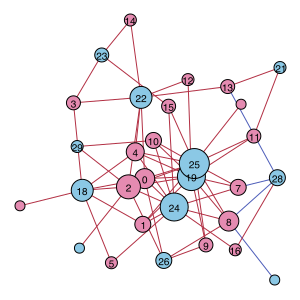

In [28]:
node_palette = {
    'host': "#73deac",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}

sign_palette = {
    'positive': "#b23044",
    'negative': "#4d5db9",
    
}

g = ig.read("scratch/randomization.network.graphml", format='graphml')
edge_colors = [sign_palette[edge['sign']] for edge in g.es]
node_colors = [node_palette[node['kingdom']] for node in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
degree_threshold = 2
normalized_sizes = [10 + 20 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
labels = [str(i) if d >= degree_threshold else "" for i, (d, v) in enumerate(zip(degrees, g.vs))]
random.seed(12412)
layout = g.layout("kk")
ig.plot(
    g, layout=layout, target='figures/network.coocurrence-bacteria-virus.byrand.svg',
    vertex_color=node_colors, edge_color=edge_colors, 

    vertex_size=normalized_sizes, vertex_label=labels, vertex_label_size=10,
    bbox=(300, 300)
)

In [26]:
network_node_labels = []
for i, (d, v) in enumerate(zip(degrees, g.vs)):
    if d >= degree_threshold:
        network_node_labels.append({"item": i, "degree": d, "name": v["id"]})
network_node_labels = pd.DataFrame.from_records(network_node_labels)
network_node_labels

,item,degree,name
0,0,6,Pepper mild mottle virus
1,1,4,Turnip yellows virus
2,2,8,Beet western yellows virus
3,3,3,Youcai mosaic virus
4,4,5,Beet chlorosis virus
5,5,2,Beet mild yellowing virus
6,7,4,Pelargonium zonate spot virus RNA 3
7,8,6,Rubus chlorotic mottle virus
8,9,3,Parietaria mottle virus RNA 3
9,10,4,Brassica yellows virus isolate


In [ ]:
A.query('sp1 == "Geodermatophilus sp. Leaf369"')

In [ ]:
bacteria_hits

In [ ]:
bacteria_hits.query('scientific_name == "Geodermatophilus sp. Leaf369"')

In [ ]:
db.close()